# Лабораторная работа 5. Градиентный бустинг

## 1. Импорт библиотек


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeRegressor
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix,
    roc_curve, auc
)
from sklearn.preprocessing import label_binarize

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
sns.set_style('whitegrid')

## 2. Загрузка данных


In [2]:
DATA_DIR = 'UCI HAR Dataset'

activity_labels = pd.read_csv(
    f'{DATA_DIR}/activity_labels.txt',
    sep=r'\s+', header=None, names=['id', 'activity']
)
activity_map = dict(zip(activity_labels['id'], activity_labels['activity']))
print('Классы активностей:')
for k, v in activity_map.items():
    print(f'  {k}: {v}')

Классы активностей:
  1: WALKING
  2: WALKING_UPSTAIRS
  3: WALKING_DOWNSTAIRS
  4: SITTING
  5: STANDING
  6: LAYING


In [3]:
X_train = pd.read_csv(f'{DATA_DIR}/train/X_train.txt', sep=r'\s+', header=None)
y_train = pd.read_csv(f'{DATA_DIR}/train/y_train.txt', sep=r'\s+', header=None).iloc[:, 0]

X_test = pd.read_csv(f'{DATA_DIR}/test/X_test.txt', sep=r'\s+', header=None)
y_test = pd.read_csv(f'{DATA_DIR}/test/y_test.txt', sep=r'\s+', header=None).iloc[:, 0]

print(f'Размер X_train: {X_train.shape}')
print(f'Размер X_test:  {X_test.shape}')
print(f'Уникальных классов: {y_train.nunique()}')

Размер X_train: (7352, 561)
Размер X_test:  (2947, 561)
Уникальных классов: 6


## 3. Разведочный анализ

Смотрим баланс классов — от этого зависит выбор метрик.

0
LAYING                1407
STANDING              1374
SITTING               1286
WALKING               1226
WALKING_UPSTAIRS      1073
WALKING_DOWNSTAIRS     986
Name: count, dtype: int64


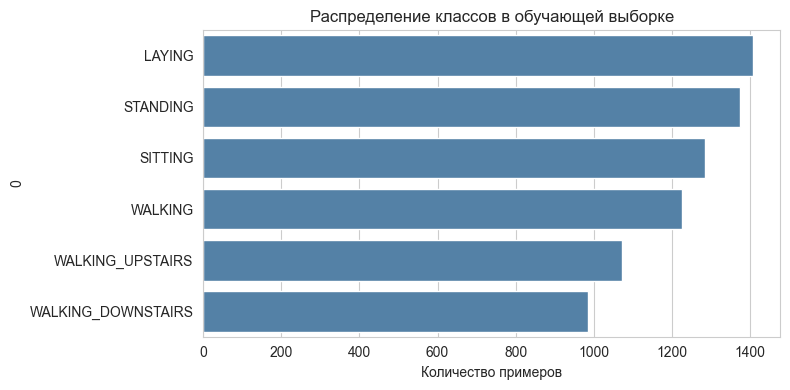

In [4]:
counts = y_train.map(activity_map).value_counts()
print(counts)

plt.figure(figsize=(8, 4))
sns.barplot(x=counts.values, y=counts.index, color='steelblue')
plt.xlabel('Количество примеров')
plt.title('Распределение классов в обучающей выборке')
plt.tight_layout()
plt.show()

Классы сбалансированы (примерно 1000–1400 примеров на класс), поэтому основная метрика accuracy, а для разбивки по классам macro-усреднённые precision, recall и F1.

## 3.5 Своя реализация градиентного бустинга

Бустинг написан с нуля: базовый слабый алгоритм — `DecisionTreeRegressor`, многоклассовость через multinomial deviance. На каждой итерации обучаем по одному дереву на класс, предсказывая антиградиент log-loss (`y_onehot - softmax(F)`), и обновляем `F += learning_rate * tree`. Итоговые вероятности — softmax от суммы деревьев.

In [5]:
class CustomGradientBoostingClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, n_estimators=100, learning_rate=0.1, max_depth=3, random_state=None):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.max_depth = max_depth
        self.random_state = random_state
        self.trees_ = []
        self.classes_ = None

    def fit(self, X, y):
        X = np.array(X)
        y = np.array(y)
        self.classes_ = np.unique(y)
        n_classes = len(self.classes_)

        y_one_hot = np.zeros((len(y), n_classes))
        for i, c in enumerate(self.classes_):
            y_one_hot[y == c, i] = 1.0

        self.F = np.zeros((len(X), n_classes))

        for m in range(self.n_estimators):
            trees_m = []
            exp_F = np.exp(self.F - np.max(self.F, axis=1, keepdims=True))
            probs = exp_F / np.sum(exp_F, axis=1, keepdims=True)

            for k in range(n_classes):
                residuals = y_one_hot[:, k] - probs[:, k]

                tree = DecisionTreeRegressor(max_depth=self.max_depth, random_state=self.random_state)
                tree.fit(X, residuals)

                self.F[:, k] += self.learning_rate * tree.predict(X)
                trees_m.append(tree)
            self.trees_.append(trees_m)
        return self

    def predict_proba(self, X):
        X = np.array(X)
        F = np.zeros((len(X), len(self.classes_)))
        for m in range(self.n_estimators):
            for k in range(len(self.classes_)):
                F[:, k] += self.learning_rate * self.trees_[m][k].predict(X)

        exp_F = np.exp(F - np.max(F, axis=1, keepdims=True))
        probs = exp_F / np.sum(exp_F, axis=1, keepdims=True)
        return probs

    def predict(self, X):
        probs = self.predict_proba(X)
        return self.classes_[np.argmax(probs, axis=1)]


## 4. Обоснование гиперпараметров

Ключевые параметры бустинга:
- **`n_estimators`** — число деревьев;
- **`learning_rate`** — шаг обучения (меньше — стабильнее, но нужно больше деревьев);
- **`max_depth`** — глубина деревьев (в бустинге берут небольшую, 3–5).

Перебираем несколько комбинаций на отложенной валидации (20% от train). На этапе подбора `n_estimators=50` для скорости.

In [ ]:

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)
print(f'train_sub: {X_tr.shape}, val: {X_val.shape}')

train_sub: (5881, 561), val: (1471, 561)


In [7]:
param_variants = [
    {'n_estimators': 50, 'learning_rate': 0.1,  'max_depth': 3},
    {'n_estimators': 50, 'learning_rate': 0.1,  'max_depth': 5},
    {'n_estimators': 50, 'learning_rate': 0.05, 'max_depth': 3},
    {'n_estimators': 50, 'learning_rate': 0.2,  'max_depth': 3},
]

results = []
for params in param_variants:
    model = CustomGradientBoostingClassifier(random_state=42, **params)
    model.fit(X_tr, y_tr)
    val_acc = accuracy_score(y_val, model.predict(X_val))
    print(f'{params} -> val accuracy = {val_acc:.4f}')
    results.append({**params, 'val_accuracy': val_acc})

results_df = pd.DataFrame(results).sort_values('val_accuracy', ascending=False)
results_df

{'n_estimators': 50, 'learning_rate': 0.1, 'max_depth': 3} -> val accuracy = 0.9558
{'n_estimators': 50, 'learning_rate': 0.1, 'max_depth': 5} -> val accuracy = 0.9708
{'n_estimators': 50, 'learning_rate': 0.05, 'max_depth': 3} -> val accuracy = 0.9497
{'n_estimators': 50, 'learning_rate': 0.2, 'max_depth': 3} -> val accuracy = 0.9613


,n_estimators,learning_rate,max_depth,val_accuracy
1,50,0.10,5,0.970768
3,50,0.20,3,0.961251
0,50,0.10,3,0.955812
2,50,0.05,3,0.949694


Итоги перебора:
- `max_depth=5` даёт лучшую val accuracy (0.9708 против 0.9558 при глубине 3);
- `learning_rate=0.05` при 50 деревьях недообучает (0.9497);
- `learning_rate=0.2` улучшает результат (0.9613), но агрессивный шаг хуже обобщается.

Для финальной модели берём `learning_rate=0.1` и `max_depth=3` (классика бустинга, меньше риск переобучения на новых людях в тесте) и увеличиваем `n_estimators` до 100.

## 5. Обучение финальной модели


In [8]:
final_model = CustomGradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

final_model.fit(X_train, y_train)
print('Модель обучена')

Модель обучена


In [9]:
y_pred = final_model.predict(X_test)
y_proba = final_model.predict_proba(X_test)

## 6. Метрики качества

accuracy, precision, recall, F1. Для многоклассовой задачи precision/recall/F1 усредняем двумя способами: **macro** (все классы равны) и **weighted** (с учётом размера класса).

In [10]:
acc = accuracy_score(y_test, y_pred)
prec_macro = precision_score(y_test, y_pred, average='macro')
rec_macro = recall_score(y_test, y_pred, average='macro')
f1_macro = f1_score(y_test, y_pred, average='macro')

prec_w = precision_score(y_test, y_pred, average='weighted')
rec_w = recall_score(y_test, y_pred, average='weighted')
f1_w = f1_score(y_test, y_pred, average='weighted')

print(f'Accuracy:           {acc:.4f}')
print(f'Precision (macro):  {prec_macro:.4f}')
print(f'Recall (macro):     {rec_macro:.4f}')
print(f'F1 (macro):         {f1_macro:.4f}')
print()
print(f'Precision (weighted): {prec_w:.4f}')
print(f'Recall (weighted):    {rec_w:.4f}')
print(f'F1 (weighted):        {f1_w:.4f}')

Accuracy:           0.9060
Precision (macro):  0.9077
Recall (macro):     0.9035
F1 (macro):         0.9044

Precision (weighted): 0.9074
Recall (weighted):    0.9060
F1 (weighted):        0.9055


In [11]:
target_names = [activity_map[i] for i in sorted(activity_map.keys())]
print(classification_report(y_test, y_pred, target_names=target_names, digits=4))

                    precision    recall  f1-score   support

           WALKING     0.8824    0.9677    0.9231       496
  WALKING_UPSTAIRS     0.9093    0.8938    0.9015       471
WALKING_DOWNSTAIRS     0.9380    0.8643    0.8996       420
           SITTING     0.8826    0.7963    0.8373       491
          STANDING     0.8342    0.8985    0.8652       532
            LAYING     1.0000    1.0000    1.0000       537

          accuracy                         0.9060      2947
         macro avg     0.9077    0.9035    0.9044      2947
      weighted avg     0.9074    0.9060    0.9055      2947



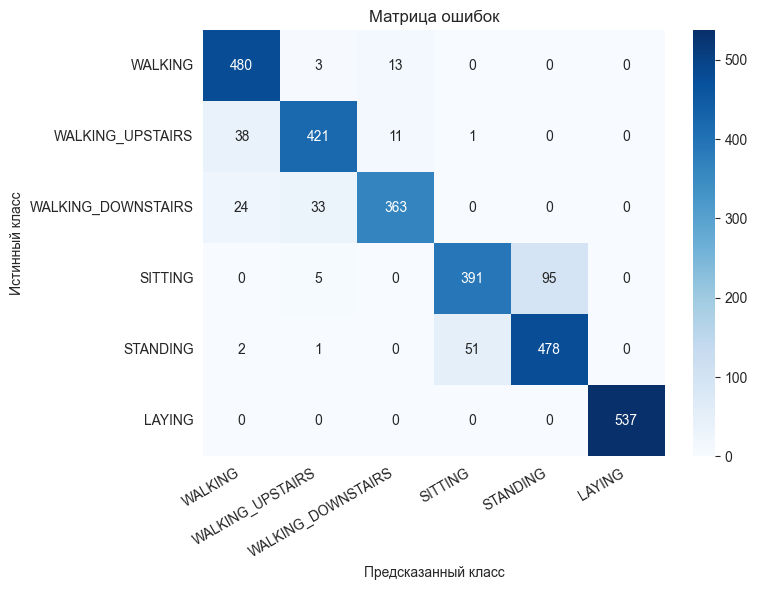

In [12]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=target_names, yticklabels=target_names
)
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.title('Матрица ошибок')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

Хуже всего различаются SITTING и STANDING: в обеих позах человек неподвижен и сигналы датчиков почти одинаковы. LAYING, наоборот, распознаётся идеально.

## 7. ROC-кривая

Задача многоклассовая, поэтому строим ROC по схеме **One-vs-Rest** (каждый класс против всех остальных) плюс общую **micro-average** кривую по всем меткам.

In [13]:
classes = sorted(y_train.unique())
y_test_bin = label_binarize(y_test, classes=classes)
n_classes = len(classes)

fpr, tpr, roc_auc = {}, {}, {}
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

fpr['micro'], tpr['micro'], _ = roc_curve(y_test_bin.ravel(), y_proba.ravel())
roc_auc['micro'] = auc(fpr['micro'], tpr['micro'])

for i, cls in enumerate(classes):
    print(f'{activity_map[cls]:<20} AUC = {roc_auc[i]:.4f}')
print(f'{"micro-average":<20} AUC = {roc_auc["micro"]:.4f}')

WALKING              AUC = 0.9970
WALKING_UPSTAIRS     AUC = 0.9921
WALKING_DOWNSTAIRS   AUC = 0.9926
SITTING              AUC = 0.9862
STANDING             AUC = 0.9849
LAYING               AUC = 1.0000
micro-average        AUC = 0.9925


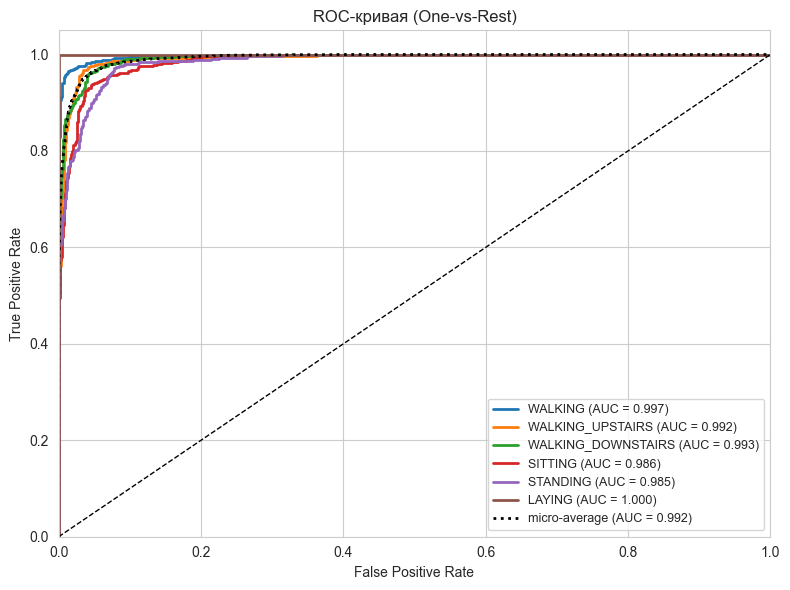

In [14]:
plt.figure(figsize=(8, 6))

colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown']
for i, cls in enumerate(classes):
    plt.plot(
        fpr[i], tpr[i], color=colors[i], lw=2,
        label=f'{activity_map[cls]} (AUC = {roc_auc[i]:.3f})'
    )

plt.plot(
    fpr['micro'], tpr['micro'], color='black', lw=2, linestyle=':',
    label=f'micro-average (AUC = {roc_auc["micro"]:.3f})'
)

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривая (One-vs-Rest)')
plt.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()